# Regressions

In [1]:
import pandas as pd
import numpy as np
from math import sqrt, pi, exp
from arch import arch_model
import yfinance as yf 
from scipy.optimize import minimize
import warnings
from arch.__future__ import reindexing
from arch.utility.exceptions import ConvergenceWarning
from src.mfiv import MFIVFiniteGridDailyNearestExpiry
from src.mfivDaily import MFIVFiniteGridDaily
from tqdm import tqdm

# suppress optimizer & runtime warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="y is poorly scaled")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## Close Price

In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/rawData")
YEARS = [2019, 2020, 2021]

d_btc_raw_by_year = {}
df_raw_by_year = {}

for y in YEARS:
    d_btc_raw_by_year[y] = pd.read_parquet(DATA_DIR / f"btc_underlying_minutely_{y}.parquet")
    df_raw_by_year[y]    = pd.read_parquet(DATA_DIR / f"derivative_data_{y}.parquet")


In [3]:
d_btc = d_btc_raw_by_year[2021]

In [4]:
d_btc = d_btc.rename(columns = {"Close" : "close"})

In [5]:
r = np.log(d_btc["close"]).diff()
d_btc["rv"] = (r ** 2) * (365 * 24)

d_btc.dropna()

,timestamp,open,high,low,close,volume,cost,date_time,rv
1,1609455660000,29103.0,29103.0,29030.5,29033.0,3.072301,89270.0,2020-12-31 23:01:00+00:00,0.051528
2,1609455720000,29033.0,29033.0,28961.5,29027.5,29.551303,857070.0,2020-12-31 23:02:00+00:00,0.000314
3,1609455780000,29028.5,29049.5,29023.0,29023.5,6.543179,189970.0,2020-12-31 23:03:00+00:00,0.000166
4,1609455840000,29028.5,29086.0,29028.5,29086.0,11.856840,344420.0,2020-12-31 23:04:00+00:00,0.040535
5,1609455900000,29082.5,29085.0,29033.5,29061.0,6.594734,191610.0,2020-12-31 23:05:00+00:00,0.006477
...,...,...,...,...,...,...,...,...,...
527035,1641077700000,47485.5,47485.5,47449.0,47471.0,1.546878,73430.0,2022-01-01 22:55:00+00:00,0.000281
527036,1641077760000,47447.0,47447.0,47447.0,47447.0,0.031403,1490.0,2022-01-01 22:56:00+00:00,0.002240
527037,1641077820000,47465.0,47465.0,47465.0,47465.0,0.025914,1230.0,2022-01-01 22:57:00+00:00,0.001260
527038,1641077880000,47458.0,47462.5,47458.0,47458.5,0.031606,1500.0,2022-01-01 22:58:00+00:00,0.000164


In [6]:
d_btc["date_time"] = pd.to_datetime(d_btc["date_time"])
d_btc = d_btc.set_index("date_time")

In [7]:
rfr = yf.download("^IRX", start=d_btc.index.min().date() - pd.Timedelta("1D"), end=d_btc.index.max().date(), progress=False)["Close"].dropna() / 100
d_btc["rfr"] = rfr.tz_localize("UTC").reindex(d_btc.index.normalize(), method="ffill").to_numpy()



In [8]:
d_btc.columns

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'cost', 'rv',
       'rfr'],
      dtype='str')

In [9]:
if isinstance(d_btc.columns, pd.MultiIndex):
    d_btc.columns = d_btc.columns.get_level_values(0)

In [10]:
d_btc.columns

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'cost', 'rv',
       'rfr'],
      dtype='str')

## Define H horizon in d_btc

In [11]:
import numpy as np

q = 0.0
HOURS = [1, 3, 168, 720]

for H in HOURS:
    T = H / (24.0 * 365.0)  # years
    d_btc[f"F{H}"] = d_btc["close"] * np.exp((d_btc["rfr"] - q) * T)


In [12]:
d_btc.columns

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'cost', 'rv',
       'rfr', 'F1', 'F3', 'F168', 'F720'],
      dtype='str')

## Options

In [13]:
df = df_raw_by_year[2021]

In [14]:
df["strike"] = df["instrument_name"].str.split("-").str[2].astype(float)
df["type"] = df["instrument_name"].str.split("-").str[3].astype(str)
df["option_price"] = df.price * df.index_price


In [15]:
# get maturity from instrument_name
df["maturity"] = pd.to_datetime(df.instrument_name.str.split("-").str[1], format = "%d%b%y")

## Rfr

In [16]:
df = df.set_index("date_time", drop = False)

In [17]:
import yfinance as yf
rfr = yf.download("^IRX", start = df.index.min().normalize() - pd.Timedelta("1D"), end= df.index.max().normalize()) ["Close"]/ 100
df["rfr"] = rfr.reindex(df.index, method = "ffill")


[*********************100%***********************]  1 of 1 completed


In [18]:
d_btc.rfr

date_time
2020-12-31 23:00:00+00:00    0.00065
2020-12-31 23:01:00+00:00    0.00065
2020-12-31 23:02:00+00:00    0.00065
2020-12-31 23:03:00+00:00    0.00065
2020-12-31 23:04:00+00:00    0.00065
                              ...   
2022-01-01 22:55:00+00:00    0.00033
2022-01-01 22:56:00+00:00    0.00033
2022-01-01 22:57:00+00:00    0.00033
2022-01-01 22:58:00+00:00    0.00033
2022-01-01 22:59:00+00:00    0.00033
Name: rfr, Length: 527040, dtype: float64

In [19]:
# # Load until now
# file_path = "../regressions/df_2021.parquet"
# df.to_parquet(file_path)
# file_path = "../regressions/d_btc_2021.parquet"
# d_btc.to_parquet(file_path)


In [20]:
df.columns

Index(['trade_seq', 'trade_id', 'timestamp', 'tick_direction', 'price',
       'mark_price', 'iv', 'instrument_name', 'index_price', 'direction',
       'amount', 'block_trade_id', 'liquidation', 'date_time', 'strike',
       'type', 'option_price', 'maturity', 'rfr'],
      dtype='str')

## Load data (2021)

In [21]:
# # Close price with hourly data
# file_path1 = "../regressions/d_btc_2021.parquet"
# file_path2 = "../regressions/df_2021.parquet"
# d_btc = pd.read_parquet(file_path1)
# df = pd.read_parquet(file_path2)


In [22]:
df[['type', 'strike', 'option_price', 'maturity','index_price', "rfr"]]

,type,strike,option_price,maturity,index_price,rfr
date_time,,,,,,
2022-01-01 22:58:53.815,C,50000.0,14236.008000,2022-12-30,47453.36,0.00033
2022-01-01 22:56:58.017,C,250000.0,213.517980,2022-06-24,47448.44,0.00033
2022-01-01 22:54:29.448,C,50000.0,9180.721665,2022-06-24,47445.59,0.00033
2022-01-01 22:54:19.829,C,70000.0,1541.626775,2022-03-25,47434.67,0.00033
2022-01-01 22:52:56.446,P,47000.0,1280.541420,2022-01-07,47427.46,0.00033
...,...,...,...,...,...,...
2020-12-31 23:02:13.305,P,30000.0,2551.385760,2021-01-15,28993.02,0.00065
2020-12-31 23:02:08.551,P,25500.0,406.298340,2021-01-08,29021.31,0.00065
2020-12-31 23:02:07.090,C,29500.0,87.104730,2021-01-01,29034.91,0.00065


In [23]:
d_btc.columns

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'cost', 'rv',
       'rfr', 'F1', 'F3', 'F168', 'F720'],
      dtype='str')

## Interpolate to get strikes (per hour)

### df11 (for calls) and df12 (for puts)

In [25]:

HOURS = [1, 3, 168, 720]
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

# assumes df has: type, strike, maturity, option_price (mid/last), and datetime index
df0 = df.copy()
df0.index = pd.to_datetime(df0.index)
df0["maturity"] = pd.to_datetime(df0["maturity"])
df0["hour"] = df0.index.floor("h")

# classify call / put
# replace the cp assignment with this (no np.where mixing strings + NaN)
t = df0["type"].astype(str).str.lower().str.strip()

df0["cp"] = pd.Series(pd.NA, index=df0.index, dtype="string")
df0.loc[t.isin(["c"]) | t.str.contains("call", na=False), "cp"] = "C"
df0.loc[t.isin(["p"]) | t.str.contains("put",  na=False), "cp"] = "P"


def spline_fill_prices(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("strike")
    x = g["strike"].to_numpy(float)
    y = g["option_price"].to_numpy(float)

    # unique strikes
    x_u, idx = np.unique(x, return_index=True)
    y_u = y[idx]

    # need enough points
    if x_u.size < 4:
        return pd.DataFrame()

    step = np.min(np.diff(x_u))
    if not np.isfinite(step) or step <= 0:
        return pd.DataFrame()

    K_grid = np.arange(x_u.min(), x_u.max() + step, step)

    cs = CubicSpline(x_u, y_u, bc_type="natural", extrapolate=False)
    p_grid = cs(K_grid)

    return pd.DataFrame({"strike": K_grid, "price": p_grid}).dropna(subset=["price"])

# ----- df11: call price surface (filled across strikes) -----
rowsC = []
# for (hour, maturity), g in df0[df0["cp"] == "C"].groupby(["hour", "maturity"]):
for (hour, maturity), g in tqdm(df0[df0["cp"] == "C"].groupby(["hour", "maturity"])):

    out = spline_fill_prices(g)
    if not out.empty:
        out.insert(0, "maturity", maturity)
        out.insert(0, "hour", hour)
        rowsC.append(out)

df11 = pd.concat(rowsC, ignore_index=True) if rowsC else pd.DataFrame(columns=["hour","maturity","strike","price"])

# ----- df12: put price surface (filled across strikes) -----
rowsP = []
# for (hour, maturity), g in df0[df0["cp"] == "P"].groupby(["hour", "maturity"]):
for (hour, maturity), g in tqdm(df0[df0["cp"] == "P"].groupby(["hour", "maturity"])):
    out = spline_fill_prices(g)
    if not out.empty:
        out.insert(0, "maturity", maturity)
        out.insert(0, "hour", hour)
        rowsP.append(out)

df12 = pd.concat(rowsP, ignore_index=True) if rowsP else pd.DataFrame(columns=["hour","maturity","strike","price"])


100%|██████████| 70626/70626 [00:48<00:00, 1465.53it/s]


In [26]:
df11.columns

Index(['hour', 'maturity', 'strike', 'price'], dtype='str')

## Compute big HFIVby_H

In [27]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from math import erf, sqrt, log, exp

# =========================
# REQUIRED INPUTS
# =========================
# df11: call price surface across strikes -> ["hour","maturity","strike","price"]
# df12: put  price surface across strikes -> ["hour","maturity","strike","price"]
# d_btc: hourly df indexed by hour with ["Close","rfr","F10","F20","F30","F40"]
H_LIST = [1, 3, 168, 720]
q = 0.0

# =========================
# BS helpers
# =========================
def _norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price(is_call, S, K, T, r, q, vol):
    if T <= 0 or vol <= 0 or S <= 0 or K <= 0:
        return np.nan
    disc_r = exp(-r * T)
    disc_q = exp(-q * T)
    vsqrtT = vol * sqrt(T)
    d1 = (log(S / K) + (r - q + 0.5 * vol * vol) * T) / vsqrtT
    d2 = d1 - vsqrtT
    if is_call:
        return S * disc_q * _norm_cdf(d1) - K * disc_r * _norm_cdf(d2)
    return K * disc_r * _norm_cdf(-d2) - S * disc_q * _norm_cdf(-d1)

def bs_implied_vol_bisect(is_call, S, K, T, r, q, price,
                          vol_lo=1e-6, vol_hi=5.0, max_iter=80, tol=1e-8):
    if T <= 0 or price <= 0:
        return np.nan
    lo, hi = vol_lo, vol_hi
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        pm = bs_price(is_call, S, K, T, r, q, mid)
        if not np.isfinite(pm):
            return np.nan
        if abs(pm - price) < tol:
            return mid
        if pm < price:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

# =========================
# MFIV variance from prices
# =========================
def mfiv_var_from_Q(K, Q, r, T_years, F,
                    m_low=0.7, m_high=1.3, n_tail=200):
    K = np.asarray(K, float)
    Q = np.asarray(Q, float)

    ok = np.isfinite(K) & np.isfinite(Q) & (K > 0) & (Q >= 0)
    K = K[ok]; Q = Q[ok]
    if K.size < 5:
        return np.nan

    idx = np.argsort(K)
    K = K[idx]; Q = Q[idx]

    # tail extension in STRIKE, flat PRICE
    K_lo = F * m_low
    K_hi = F * m_high

    left_tail = np.logspace(np.log10(K_lo), np.log10(K[0]), n_tail, endpoint=False) if K_lo < K[0] else []
    right_tail = np.logspace(np.log10(K[-1]), np.log10(K_hi), n_tail) if K_hi > K[-1] else []

    K_ext = np.unique(np.concatenate([left_tail, K, right_tail]))
    Q_ext = np.interp(K_ext, K, Q, left=Q[0], right=Q[-1])

    integrand = Q_ext / (K_ext ** 2)
    integral = np.trapezoid(integrand, K_ext)

    var = (2.0 * np.exp(r * T_years) / T_years) * integral
    return var if np.isfinite(var) and var > 0 else np.nan

# =========================
# CLEAN TIME INDEX
# =========================
d_btc = d_btc.copy()
d_btc.index = pd.to_datetime(d_btc.index).tz_localize(None)

# =========================
# BUILD MFIV_byH
# =========================
MFIV_byH = {}

for H in H_LIST:
    T_years = H / (24.0 * 365.0)

    rows = []

    # combine calls + puts (NO maturity interpolation)
    CP = pd.merge(
        df11, df12,
        on=["hour", "maturity", "strike"],
        how="outer",
        suffixes=("_C", "_P")
    )
    CP["hour"] = pd.to_datetime(CP["hour"]).dt.tz_localize(None)
    CP["maturity"] = pd.to_datetime(CP["maturity"]).dt.tz_localize(None)
    CP["T_hours"] = (CP["maturity"] - CP["hour"]).dt.total_seconds() / 3600.0

    for hour, g in tqdm(CP.groupby("hour"), total=CP["hour"].nunique()):
        if hour not in d_btc.index:
            continue

        S = float(d_btc.loc[hour, "close"])
        r = float(d_btc.loc[hour, "rfr"])
        F = float(d_btc.loc[hour, f"F{H}"])

        # nearest maturity to H
        g = g.loc[(g["T_hours"] - H).abs().groupby(g["strike"]).idxmin()]
        
        K = g["strike"].to_numpy(float)
        C = g["price_C"].to_numpy(float)
        P = g["price_P"].to_numpy(float)

        Q = np.full_like(K, np.nan)
        Q[K < F] = P[K < F]
        Q[K > F] = C[K > F]

        # coverage filter
        m = K / F
        if m.min() > 0.85 or m.max() < 1.15:
            continue

        mfiv_var = mfiv_var_from_Q(K, Q, r, T_years, F)
        if not np.isfinite(mfiv_var):
            continue

        # ATM BSIV from nearest-maturity price
        atm_i = np.abs(K - F).argmin()
        px = C[atm_i] if K[atm_i] >= F else P[atm_i]
        is_call = K[atm_i] >= F

        bsIV = bs_implied_vol_bisect(is_call, S, K[atm_i], T_years, r, q, px)
        if not np.isfinite(bsIV):
            continue

        rows.append((hour, bsIV, mfiv_var))

    df_out = pd.DataFrame(rows, columns=["hour", "bsIV", "MFIV"]).set_index("hour").sort_index()
    MFIV_byH[H] = df_out


100%|██████████| 8688/8688 [00:04<00:00, 1819.07it/s]


So mathematically / methodologically:
same spline-filled call/put surfaces
same nearest-maturity-to-H selection
same OTM Q(K) construction
same MFIV integral
same ATM BSIV extraction

In [29]:
MFIV_byH[3]

,bsIV,MFIV
hour,,
2020-12-31 23:00:00,1.785992,60.738812
2021-01-01 00:00:00,2.164542,79.537700
2021-01-01 01:00:00,0.498854,358.764052
2021-01-01 02:00:00,2.970701,77.661367
2021-01-01 04:00:00,2.680758,31.988334
...,...,...
2022-01-01 12:00:00,1.875062,69.587930
2022-01-01 14:00:00,0.000001,55.657583
2022-01-01 15:00:00,1.398689,32.949901


### These are not the same scale right now 
bsIV is volatility (sigma)
MFIV is variance (sigma square)

df1: <br>
Contains missing strikes between the highest strike and the lowest strike available in scope<br>
every hour, separately, and per expiry.


## Regressions

### Contemporary association check

In [27]:
import statsmodels.api as sm
df_reg = (
    MFIV_byH[H][["bsIV", "MFIV"]]
    .join(d_btc[["rv"]], how="inner")
    .dropna(subset=["rv", "MFIV", "bsIV"])
)

df_reg["bsIV_var"] = df_reg["bsIV"] ** 2
df_reg["MFIV"] = df_reg["MFIV"] / 100

df_reg = df_reg.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_reg["rv"], errors="coerce")

mask = (
    np.isfinite(y)
    & np.isfinite(df_reg["MFIV"])
    & np.isfinite(df_reg["bsIV_var"])
)

y = y.loc[mask]
df_reg = df_reg.loc[mask]

X_A = sm.add_constant(df_reg["MFIV"])
res_A = sm.OLS(y, X_A).fit(cov_type="HAC", cov_kwds={"maxlags": H})

X_B = sm.add_constant(df_reg["bsIV_var"])
res_B = sm.OLS(y, X_B).fit(cov_type="HAC", cov_kwds={"maxlags": H})

X_C = sm.add_constant(df_reg[["MFIV", "bsIV_var"]])
res_C = sm.OLS(y, X_C).fit(cov_type="HAC", cov_kwds={"maxlags": H})

In [28]:
print(type(y))
print(np.shape(y))
print(len(df_reg))

<class 'pandas.Series'>
(7620,)
7620


In [29]:
table_10h = pd.DataFrame({
    "Spec A (MFIV)": [
        res_A.params["const"], res_A.params["MFIV"],
        res_A.rsquared, res_A.nobs
    ],
    "Spec B (BSIV)": [
        res_B.params["const"], res_B.params["bsIV_var"],
        res_B.rsquared, res_B.nobs
    ],
    "Spec C (Both)": [
        res_C.params["const"], res_C.params["MFIV"],
        res_C.rsquared, res_C.nobs
    ],
}, index=["Intercept", "MFIV", "Adj_R2", "N"])

table_10h


,Spec A (MFIV),Spec B (BSIV),Spec C (Both)
Intercept,0.019270,0.025020,0.016592
MFIV,0.014377,0.001160,0.013152
Adj_R2,0.004346,0.002183,0.005739
N,7620.000000,7620.000000,7620.000000


So the regressions are:
Spec A: variance on variance
Spec B: variance on variance
Spec C: variance on variance + variance

MFIV contains more information than BSIV, but overall explanatory power is still very low → weak linear relationship with your RV.


### Multi Regression

In [ ]:
rows = []

for H in sorted(MFIV_byH.keys()):
    df_reg = (
        MFIV_byH[H][["bsIV", "MFIV"]]
        .join(d_btc[["rv"]], how="inner")
        .dropna(subset=["rv", "MFIV", "bsIV"])
        .copy()
    )

    df_reg["bsIV_var"] = df_reg["bsIV"] ** 2
    df_reg["MFIV"] = df_reg["MFIV"] / 100

    df_reg = df_reg.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(df_reg["rv"], errors="coerce")

    mask = (
        np.isfinite(y)
        & np.isfinite(df_reg["MFIV"])
        & np.isfinite(df_reg["bsIV_var"])
    )

    y = y.loc[mask]
    df_reg = df_reg.loc[mask]

    X_A = sm.add_constant(df_reg["MFIV"])
    res_A = sm.OLS(y, X_A).fit(cov_type="HAC", cov_kwds={"maxlags": H})

    X_B = sm.add_constant(df_reg["bsIV_var"])
    res_B = sm.OLS(y, X_B).fit(cov_type="HAC", cov_kwds={"maxlags": H})

    X_C = sm.add_constant(df_reg[["MFIV", "bsIV_var"]])
    res_C = sm.OLS(y, X_C).fit(cov_type="HAC", cov_kwds={"maxlags": H})

    rows.append({
        "H": H,
        "A_Intercept": res_A.params["const"],
        "A_MFIV": res_A.params["MFIV"],
        "A_R2": res_A.rsquared,
        "B_Intercept": res_B.params["const"],
        "B_BSIV2": res_B.params["bsIV_var"],
        "B_R2": res_B.rsquared,
        "C_Intercept": res_C.params["const"],
        "C_MFIV": res_C.params["MFIV"],
        "C_BSIV2": res_C.params["bsIV_var"],
        "C_R2": res_C.rsquared,
        "N": int(res_A.nobs)
    })

table_all_H = pd.DataFrame(rows).set_index("H")
table_all_H

,A_Intercept,A_MFIV,A_R2,B_Intercept,B_BSIV2,B_R2,C_Intercept,C_MFIV,C_BSIV2,C_R2,N
H,,,,,,,,,,,
5,0.018915,0.014881,0.004645,0.024432,0.001297,0.002791,0.015796,0.013469,0.001073,0.006513,7620
8,0.018845,0.023925,0.004696,0.025837,0.001326,0.001846,0.016890,0.022128,0.001022,0.005766,7621
12,0.018656,0.036423,0.004844,0.026115,0.001644,0.001876,0.016994,0.033617,0.001246,0.005891,7621
15,0.018509,0.046022,0.004958,0.026010,0.001979,0.002187,0.016839,0.042067,0.001521,0.006212,7621
20,0.018277,0.062372,0.005152,0.026362,0.002172,0.001914,0.016949,0.057397,0.001583,0.006136,7621
25,0.017817,0.080595,0.005530,0.025778,0.002932,0.002730,0.016220,0.072538,0.002229,0.007052,7621
30,0.017721,0.096862,0.005559,0.025793,0.003241,0.002652,0.016161,0.087299,0.002437,0.007004,7621
40,0.017640,0.129589,0.005601,0.026232,0.003608,0.002211,0.016361,0.118401,0.002612,0.006718,7621
50,0.017430,0.163732,0.005737,0.026124,0.004295,0.002302,0.016121,0.149269,0.003101,0.006892,7621


MFIV gets stronger as horizon increases
BSIV contributes almost nothing
MFIV dominates in all specs
Rsq is low across all horizons
Linear relationship is weak


### Forecasting Regression on Forward H-Hour Realized Variance
Forward target is now used instead of same-hour RV
y is now the next H-hour realized variance sum


In [30]:
H = 5
df_reg = MFIV_byH[H][["bsIV", "MFIV"]].copy()
df_reg["rv"] = d_btc["rv"].reindex(df_reg.index)
df_reg = df_reg.dropna(subset=["rv", "MFIV", "bsIV"])


# 1) Forward realized variance (H-hour horizon)
y = df_reg["rv"].rolling(H).sum().shift(-(H - 1))
df_reg = df_reg.iloc[:-(H - 1)].copy()
y = y.iloc[:-(H - 1)]

# 2) Put all regressors on variance scale
df_reg["bsIV_var"] = df_reg["bsIV"] ** 2


# 3) Enforce numeric + clean alignment
df_reg = df_reg.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

mask = (
    np.isfinite(y)
    & np.isfinite(df_reg["MFIV"])
    & np.isfinite(df_reg["bsIV_var"])
)

y = y[mask]
df_reg = df_reg.loc[mask]


# 4) Regressions (HAC standard errors)

# Spec A: RV ~ MFIV
X_A = sm.add_constant(df_reg["MFIV"])
res_A = sm.OLS(y, X_A).fit(cov_type="HAC", cov_kwds={"maxlags": H})

# Spec B: RV ~ BSIV^2
X_B = sm.add_constant(df_reg["bsIV_var"])
res_B = sm.OLS(y, X_B).fit(cov_type="HAC", cov_kwds={"maxlags": H})

# Spec C: RV ~ MFIV + BSIV^2
X_C = sm.add_constant(df_reg[["MFIV", "bsIV_var"]])
res_C = sm.OLS(y, X_C).fit(cov_type="HAC", cov_kwds={"maxlags": H})


In [31]:
table_5h = pd.DataFrame(
    {
        "Spec A (MFIV)": [
            res_A.params["const"],
            res_A.params["MFIV"],
            np.nan,
            res_A.rsquared_adj,
            int(res_A.nobs),
        ],
        "Spec B (BSIV^2)": [
            res_B.params["const"],
            np.nan,
            res_B.params["bsIV_var"],
            res_B.rsquared_adj,
            int(res_B.nobs),
        ],
        "Spec C (Both)": [
            res_C.params["const"],
            res_C.params["MFIV"],
            res_C.params["bsIV_var"],
            res_C.rsquared_adj,
            int(res_C.nobs),
        ],
    },
    index=["Intercept", "MFIV", "BSIV^2", "Adj_R2", "N"],
)

table_5h


,Spec A (MFIV),Spec B (BSIV^2),Spec C (Both)
Intercept,0.095575,0.126030,0.082930
MFIV,0.000730,NaN,0.000672
BSIV^2,NaN,0.005564,0.004425
Adj_R2,0.016333,0.007243,0.020765
N,7616.000000,7616.000000,7616.000000


- bsIV: implied volatility sigma in per-year units (dimensionless, e.g. 0.20 = 20% annualized)
- MFIV: model-free implied variance rate in per-year variance units (i.e. sigma square annualized)

### Conclusions

MFIV is statistically relevant but effect size is modest
BSIV² has weak standalone explanatory power
R² remains low, so most variation is still unexplained

Improvement may come from the right horizon alignment, not model strength

### Multi-Horizon Forward Variance Regression


In [ ]:
rows = []

for H in sorted(MFIV_byH.keys()):
    df_reg = MFIV_byH[H][["bsIV", "MFIV"]].copy()
    df_reg["rv"] = d_btc["rv"].reindex(df_reg.index)
    df_reg = df_reg.dropna(subset=["rv", "MFIV", "bsIV"])

    # 1) Forward realized variance (H-hour horizon)
    y = df_reg["rv"].rolling(H).sum().shift(-(H - 1))
    df_reg = df_reg.iloc[:-(H - 1)].copy()
    y = y.iloc[:-(H - 1)]

    # 2) Put all regressors on variance scale
    df_reg["bsIV_var"] = df_reg["bsIV"] ** 2
    df_reg["MFIV"] = df_reg["MFIV"] / 100

    # 3) Enforce numeric + clean alignment
    df_reg = df_reg.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    mask = (
        np.isfinite(y)
        & np.isfinite(df_reg["MFIV"])
        & np.isfinite(df_reg["bsIV_var"])
    )

    y = y.loc[mask]
    df_reg = df_reg.loc[mask]

    # 4) Regressions (HAC standard errors)
    X_A = sm.add_constant(df_reg["MFIV"])
    res_A = sm.OLS(y, X_A).fit(cov_type="HAC", cov_kwds={"maxlags": H})

    X_B = sm.add_constant(df_reg["bsIV_var"])
    res_B = sm.OLS(y, X_B).fit(cov_type="HAC", cov_kwds={"maxlags": H})

    X_C = sm.add_constant(df_reg[["MFIV", "bsIV_var"]])
    res_C = sm.OLS(y, X_C).fit(cov_type="HAC", cov_kwds={"maxlags": H})

    rows.append({
        "H": H,
        "A_Intercept": res_A.params["const"],
        "A_MFIV": res_A.params["MFIV"],
        "A_R2": res_A.rsquared,
        "B_Intercept": res_B.params["const"],
        "B_BSIV2": res_B.params["bsIV_var"],
        "B_R2": res_B.rsquared,
        "C_Intercept": res_C.params["const"],
        "C_MFIV": res_C.params["MFIV"],
        "C_BSIV2": res_C.params["bsIV_var"],
        "C_R2": res_C.rsquared,
        "N": int(res_A.nobs)
    })

table_forward_all_H = pd.DataFrame(rows).set_index("H")
table_forward_all_H

,A_Intercept,A_MFIV,A_R2,B_Intercept,B_BSIV2,B_R2,C_Intercept,C_MFIV,C_BSIV2,C_R2,N
H,,,,,,,,,,,
5,0.094069,0.075153,0.017401,0.124047,0.006000,0.008775,0.079945,0.068764,0.004856,0.023024,7616
8,0.156429,0.178769,0.020884,0.211278,0.008946,0.006698,0.143692,0.167078,0.006654,0.024500,7614
12,0.239759,0.384132,0.024511,0.323296,0.014929,0.007038,0.225510,0.360134,0.010667,0.028008,7610
15,0.300131,0.597227,0.027767,0.403785,0.022049,0.009029,0.282566,0.555643,0.015993,0.032382,7607
20,0.403269,1.040375,0.031818,0.547273,0.029815,0.008015,0.386632,0.978204,0.019802,0.035240,7602
25,0.496375,1.668473,0.038307,0.681274,0.044660,0.010247,0.475159,1.561765,0.029559,0.042639,7597
30,0.589489,2.439234,0.043976,0.818852,0.058602,0.010832,0.565384,2.292077,0.037558,0.048265,7592
40,0.775121,4.447896,0.054800,1.100945,0.089600,0.011348,0.748372,4.215925,0.054318,0.058822,7582
50,0.954394,7.099184,0.064225,1.374353,0.131704,0.012924,0.921137,6.735988,0.078191,0.068612,7572


### Conclusions
MFIV picks up with horizon, finally shows some signal
BSIV barely moves, still weak even at higher H
Combined model gains a bit but nothing dramatic
Fit improves with H but still low overall
Most of the action is just coming from horizon alignment, not model strength


### New regression

In [33]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# choose the horizons that match your equation

Hs =[1, 3, 168, 720]

# build one wide dataframe
df_multi = d_btc[["rv"]].copy()

for H in Hs:
    df_h = MFIV_byH[H][["MFIV"]].copy()
    df_h = df_h.rename(columns={"MFIV": f"IV_{H}"})
    df_multi = df_multi.join(df_h, how="inner")

# clean
df_multi = df_multi.apply(pd.to_numeric, errors="coerce")
df_multi = df_multi.replace([np.inf, -np.inf], np.nan).dropna()

y = df_multi["rv"]
X = sm.add_constant(df_multi[[f"IV_{H}" for H in Hs]] / 100)

# estimate
res_multi = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": max(Hs)})

print(res_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     1118.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:31:57   Log-Likelihood:                 4702.1
No. Observations:                7620   AIC:                            -9394.
Df Residuals:                    7615   BIC:                            -9360.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0102      0.006     -1.645      0.1

## More information Tables

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

# -----------------------------
# 0) choose horizon
# -----------------------------
H = 20

# -----------------------------
# 1) build regression dataset
# -----------------------------
df_reg = (
    MFIV_byH[H][["bsIV", "MFIV"]]
    .join(d_btc[["rv"]], how="inner")
    .dropna(subset=["rv", "MFIV", "bsIV"])
)

# forward realized VARIANCE over next H hours
y_var = df_reg["rv"].rolling(H).sum().shift(-(H - 1))
df_reg = df_reg.iloc[:-(H - 1)].copy()
y_var = y_var.iloc[:-(H - 1)]

# BS to variance scale
df_reg["bsIV_var"] = df_reg["bsIV"] ** 2

# LRE proxy (lagged forward variance)
df_reg["LRE"] = y_var.shift(1)

# numeric + clean
df_reg = df_reg.apply(pd.to_numeric, errors="coerce")
y_var = pd.to_numeric(y_var, errors="coerce")

mask = (
    np.isfinite(y_var)
    & np.isfinite(df_reg["MFIV"])
    & np.isfinite(df_reg["bsIV_var"])
    & np.isfinite(df_reg["LRE"])
)

df_reg = df_reg.loc[mask]
y_var = y_var.loc[mask]

# -----------------------------
# 2) targets (PAPER STYLE)
# A: sigma_t ; B: V_t ; C: ln V_t
# -----------------------------
yA = np.sqrt(y_var)                                  # σ_t
yB = y_var                                           # V_t
yC = np.log(y_var.replace(0, np.nan)).dropna()       # ln V_t (drop zeros)

dfA = df_reg.loc[yA.index]
dfB = df_reg.loc[yB.index]
dfC = df_reg.loc[yC.index]

# regressors
X_MF_A, X_BS_A, X_LRE_A = dfA[["MFIV"]], dfA[["bsIV_var"]], dfA[["LRE"]]
X_MF_B, X_BS_B, X_LRE_B = dfB[["MFIV"]], dfB[["bsIV_var"]], dfB[["LRE"]]
X_MF_C, X_BS_C, X_LRE_C = dfC[["MFIV"]], dfC[["bsIV_var"]], dfC[["LRE"]]

# -----------------------------
# 3) helpers
# -----------------------------
def stars(p):
    return "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))

def coef_se(res, name):
    if name not in res.params:
        return "—"
    return f"{res.params[name]:.2f}{stars(res.pvalues[name])} ({res.bse[name]:.3f})"

def wald(res, pairs):
    p = list(res.params.index)
    R = np.zeros((len(pairs), len(p)))
    q = np.zeros(len(pairs))
    for i, (k, v) in enumerate(pairs):
        if k not in p:
            return "—"
        R[i, p.index(k)] = 1.0
        q[i] = v
    w = res.wald_test((R, q), scalar=True)
    return f"{float(w.statistic):.2f} ({float(w.pvalue):.3f})"

def run(y, X):
    X = sm.add_constant(X)
    return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": H})

def panel(y, X_MF, X_BS, X_LRE, name):
    rows = []

    # BS only
    res = run(y, X_BS)
    rows.append([name, res.nobs, coef_se(res,"const"), "—", coef_se(res,"bsIV_var"), "—",
                 f"{res.rsquared_adj:.2f}", f"{durbin_watson(res.resid):.2f}",
                 wald(res,[("const",0),("bsIV_var",1)]), "—"])

    # MF only
    res = run(y, X_MF)
    rows.append([name, res.nobs, coef_se(res,"const"), coef_se(res,"MFIV"), "—", "—",
                 f"{res.rsquared_adj:.2f}", f"{durbin_watson(res.resid):.2f}",
                 wald(res,[("const",0),("MFIV",1)]), "—"])

    # MF + BS (encompassing)
    res = run(y, X_MF.join(X_BS))
    rows.append([name, res.nobs, coef_se(res,"const"), coef_se(res,"MFIV"), coef_se(res,"bsIV_var"), "—",
                 f"{res.rsquared_adj:.2f}", f"{durbin_watson(res.resid):.2f}",
                 "—", wald(res,[("MFIV",1),("bsIV_var",0)])])

    return pd.DataFrame(rows, columns=[
        "Panel","N","a","β^MF","β^BS","β^LRE","Adj_R2","DW","chi2(a)","chi2(b)"
    ])

# -----------------------------
# 4) build final table
# -----------------------------
table4_like = pd.concat([
    panel(yA, X_MF_A, X_BS_A, X_LRE_A, "A: σ_t (sqrt forward RV)"),
    panel(yB, X_MF_B, X_BS_B, X_LRE_B, "B: V_t (forward RV)"),
    panel(yC, X_MF_C, X_BS_C, X_LRE_C, "C: ln V_t"),
], ignore_index=True)

table4_like


,Panel,N,a,β^MF,β^BS,β^LRE,Adj_R2,DW,chi2(a),chi2(b)
0,A: σ_t (sqrt forward RV),7583.0,2.29*** (0.041),—,0.42** (0.185),—,0.07,0.16,7282.93 (0.000),—
1,A: σ_t (sqrt forward RV),7583.0,2.29*** (0.028),0.02*** (0.005),—,—,0.01,0.05,37177.03 (0.000),—
2,A: σ_t (sqrt forward RV),7583.0,2.23*** (0.039),0.02*** (0.005),0.41** (0.182),—,0.08,0.17,—,48985.81 (0.000)
3,B: V_t (forward RV),7583.0,5.48*** (0.220),—,2.35** (1.038),—,0.08,0.17,1739.85 (0.000),—
4,B: V_t (forward RV),7583.0,5.54*** (0.141),0.12*** (0.028),—,—,0.01,0.05,2073.94 (0.000),—
5,B: V_t (forward RV),7583.0,5.19*** (0.204),0.09*** (0.024),2.27** (1.022),—,0.08,0.18,—,1402.37 (0.000)
6,C: ln V_t,7583.0,1.60*** (0.033),—,0.33** (0.140),—,0.07,0.15,5035.71 (0.000),—
7,C: ln V_t,7583.0,1.61*** (0.024),0.02*** (0.004),—,—,0.01,0.05,60266.07 (0.000),—
8,C: ln V_t,7583.0,1.56*** (0.032),0.01*** (0.004),0.31** (0.138),—,0.07,0.16,—,76904.10 (0.000)


Changing from σ to V applies a nonlinear transformation, so coefficients are not just rescaled but change in magnitude and relative proportions, altering how strongly each variable appears to matter, even though overall fit and statistical significance remain unchanged.

BS relative to MF increases under variance scale
σ: β^BS / β^MF ≈ 0.41 / 0.02 ≈ 20
V: β^BS / β^MF ≈ 2.27 / 0.09 ≈ 25

MF relative to BS decreases slightly under variance scale
σ: β^MF / β^BS ≈ 0.02 / 0.41 ≈ 0.05
V: β^MF / β^BS ≈ 0.09 / 2.27 ≈ 0.04


In [117]:
# print(table4_like.to_latex(index=False, escape=False))
print(pd.DataFrame(table4_like).to_latex(index=False, escape=False))


\begin{tabular}{lrllllllll}
\toprule
Panel & N & a & β^MF & β^BS & β^LRE & Adj_R2 & DW & chi2(a) & chi2(b) \\
\midrule
A: V_t (forward variance) & 7615.000000 & 0.13*** (0.007) & — & 0.01*** (0.002) & — & 0.01 & 0.29 & 442303.87 (0.000) & — \\
A: V_t (forward variance) & 7615.000000 & 0.10*** (0.007) & 0.00*** (0.000) & — & — & 0.02 & 0.30 & 85241333.49 (0.000) & — \\
A: V_t (forward variance) & 7615.000000 & 0.08*** (0.009) & 0.00*** (0.000) & 0.00*** (0.001) & — & 0.02 & 0.31 & — & 123273212.70 (0.000) \\
B: ln V_t & 7615.000000 & -2.71*** (0.029) & — & 0.02*** (0.004) & — & 0.01 & 0.23 & 108950.43 (0.000) & — \\
B: ln V_t & 7615.000000 & -2.90*** (0.033) & 0.00*** (0.000) & — & — & 0.04 & 0.29 & 14751486.73 (0.000) & — \\
B: ln V_t & 7615.000000 & -2.93*** (0.035) & 0.00*** (0.000) & 0.01*** (0.003) & — & 0.04 & 0.29 & — & 10676474.57 (0.000) \\
C: ΔV_t & 7614.000000 & -0.00 (0.002) & — & 0.00 (0.001) & — & -0.00 & 1.87 & 5631008.60 (0.000) & — \\
C: ΔV_t & 7614.000000 & 0.00 (0.003

## Data Checks

Two things depend on the below data analysis, 
The first is to understand the strength of inference made from the MFIV. 
For instance bad quality data in 2019 (sparce IV surface with minimal strikes) shown in the Surfaces section of this project is one reason.
The second is whether the data will suffice an entire market class to simulate hourly trading.

### Plot interpolated max and min strikes available

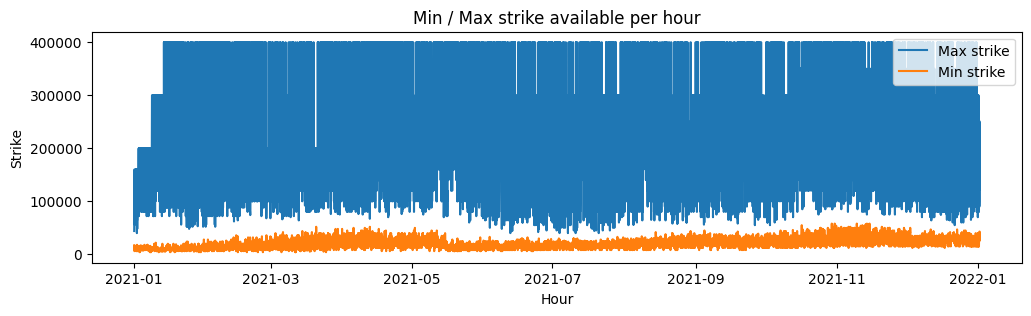

In [ ]:

# It maps every option quote timestamp to the start of its hour, so all quotes within the same hour share the same hour label (e.g 10:00–10:59 to 10:00)
import matplotlib.pyplot as plt

# assume df has datetime index and 'strike'
df0 = df.copy()
df0.index = pd.to_datetime(df0.index)
df0["hour"] = df0.index.floor("h")

# max and min strike per hour
agg = (
    df0.groupby("hour")["strike"]
       .agg(min_strike="min", max_strike="max")
)

# plot max strike (add min if you want)
plt.figure(figsize = (12,3))
plt.plot(agg.index, agg["max_strike"], label="Max strike")
plt.plot(agg.index, agg["min_strike"], label="Min strike")
plt.xlabel("Hour")
plt.ylabel("Strike")
plt.title("Min / Max strike available per hour")
plt.legend()
plt.show()


### Closer look into 2021 January

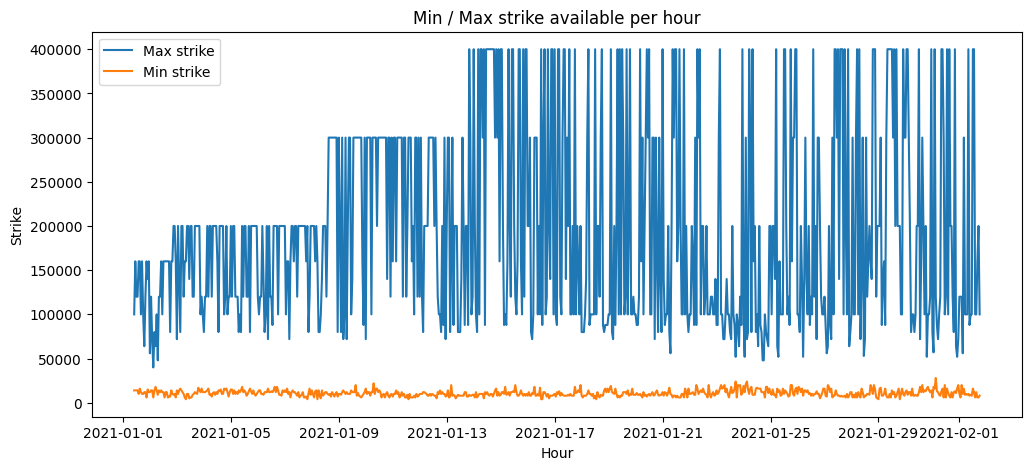

In [121]:
agg_sub = agg.loc["2021-01-01 10:00":"2021-02-01 18:00"]

plt.figure(figsize = (12,5))
plt.plot(agg_sub.index, agg_sub["max_strike"], label="Max strike")
plt.plot(agg_sub.index, agg_sub["min_strike"], label="Min strike")
plt.xlabel("Hour")
plt.ylabel("Strike")
plt.title("Min / Max strike available per hour")
plt.legend()
plt.show()


### Check no. of days or hours left to maturity 

In [123]:
import pandas as pd

idx: pd.DatetimeIndex = pd.to_datetime(df.index)
df = df.copy()
df.index = idx

df["hour"] = df.index.floor("h")
df["minute"] = df.index.floor("min")

maturity_ts = pd.to_datetime(df["maturity"])
df["dte_days"] = (maturity_ts - df.index).dt.total_seconds() / 86400.0

# count unique maturities (DTEs) per minute, within each hour
counts = (
    df.groupby(["hour", "minute"])["dte_days"]
      .nunique()
      .rename("n_unique_maturities_in_minute")
)

counts


hour                 minute             
2020-12-31 23:00:00  2020-12-31 23:00:00    1
                     2020-12-31 23:01:00    1
                     2020-12-31 23:02:00    7
                     2020-12-31 23:07:00    1
                     2020-12-31 23:09:00    2
                                           ..
2022-01-01 22:00:00  2022-01-01 22:50:00    1
                     2022-01-01 22:52:00    2
                     2022-01-01 22:54:00    2
                     2022-01-01 22:56:00    1
                     2022-01-01 22:58:00    1
Name: n_unique_maturities_in_minute, Length: 397786, dtype: int64

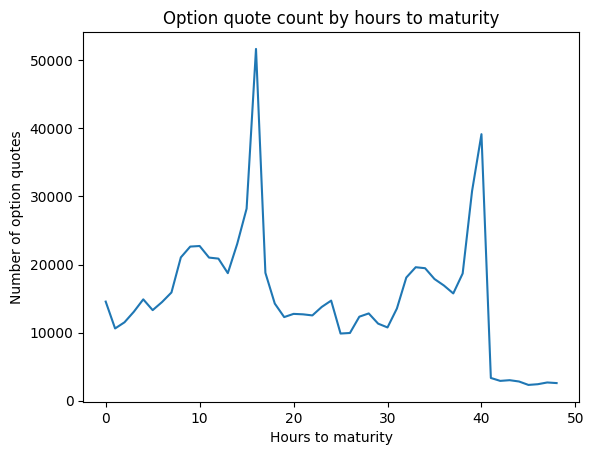

In [124]:
import pandas as pd
import matplotlib.pyplot as plt

df = df.copy()
df.index = pd.to_datetime(df.index)
df["maturity"] = pd.to_datetime(df["maturity"])

# HOURS to maturity (calendar hours)
df["hours_to_maturity"] = (
    (df["maturity"] - df.index).dt.total_seconds() / 3600.0
)

# Bin options by distance to expiry rounded to 1 hour.
h_binned = df["hours_to_maturity"].round(0)

# count option quotes at each hours-to-maturity
counts = (
    h_binned
    .value_counts()
    .sort_index()
)

subCounts = counts.loc[(counts.index >= 0) & (counts.index <= 48)]

# plot
plt.figure()
plt.plot(subCounts.index, subCounts.values)
plt.xlabel("Hours to maturity")
plt.ylabel("Number of option quotes")
plt.title("Option quote count by hours to maturity")
plt.show()


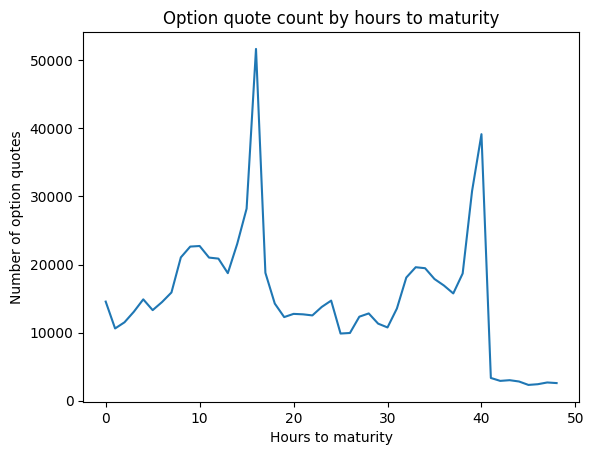

In [125]:
subCounts = counts.loc[(counts.index >= 0) & (counts.index <= 48)]

# plot
plt.figure()
plt.plot(subCounts.index, subCounts.values)
plt.xlabel("Hours to maturity")
plt.ylabel("Number of option quotes")
plt.title("Option quote count by hours to maturity")
plt.show()


### What proportion of minutes have trades in them ?

In [127]:
# Convert index to minute resolution
minutes_with_options = df.index.floor("min")

# how many unique index minutes exist in df
n_active_minutes = minutes_with_options.nunique()

# Total minutes in the covered year span
start = df.index.min().floor("min")
end   = df.index.max().ceil("min")
total_minutes = int((end - start).total_seconds() / 60) + 1

# proportion
proportion = n_active_minutes / total_minutes
print(f"In the observed time window, {proportion:.3f} of minutes had ≥1 option trade.")

In the observed time window, 0.755 of minutes had ≥1 option trade.


 while 2025 had over 0.95 of the minutes

In [129]:
print(start)
print(end)


2020-12-31 23:00:00
2022-01-01 22:59:00


With this, we can take 2021 as the best year in-sample for making statistical inference using the options data.